## linear regression

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [25]:
df = pd.read_csv('height-weight.csv')

In [26]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

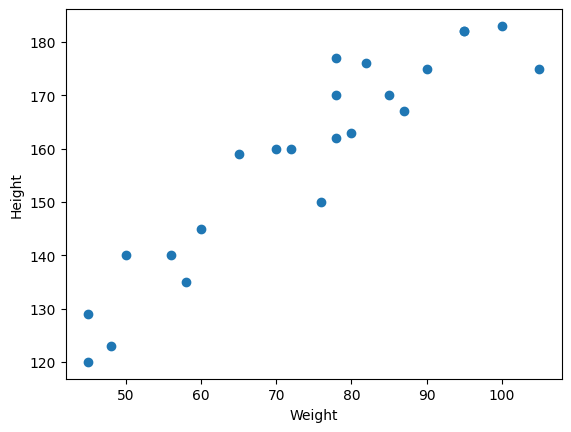

In [27]:
## scatter plots
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [28]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


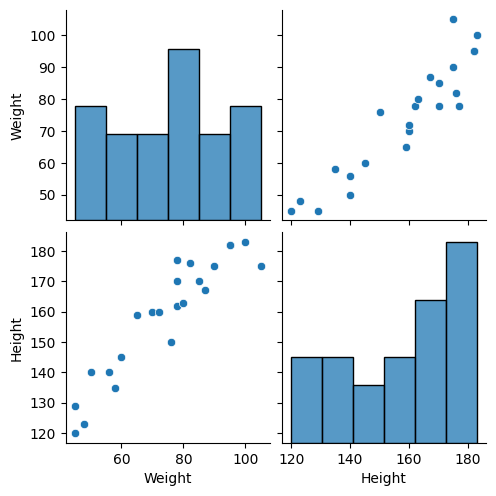

In [29]:
sns.pairplot(df)

In [30]:
## independent and dependent features
X = df[['Weight']]  ## remenber your independent feature should be always in the form of dataframe or 2D array.
y = df['Height'] ## these variable can in series form or 1d array
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [31]:
X_series = df['Weight']
X_series

0      45
1      58
2      48
3      60
4      70
5      78
6      80
7      90
8      95
9      78
10     82
11     95
12    105
13    100
14     85
15     78
16     50
17     65
18     76
19     87
20     45
21     56
22     72
Name: Weight, dtype: int64

In [32]:
## Train Test Split
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state=42)

In [34]:
X_train.shape

(17, 1)

In [35]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)


In [37]:
# # ================= STANDARDIZATION, DATA LEAKAGE, fit_transform vs transform =================

# # Standardization:
# # - A preprocessing technique used to put features on a common scale.
# # - It converts values into "how many standard deviations away from the mean they are".
# #
# # Formula:
# #       z = (x - mean) / standard_deviation
# #
# # After standardization:
# #       mean = 0
# #       standard deviation = 1
# #       range = no fixed range (-infinity to +infinity)
# #
# # Unlike Normalization:
# #       Normalization -> scales data to fixed range (usually 0 to 1)
# #       Standardization -> centers data around 0 with std = 1


# # Why standardization is needed:
# # - Features can have different scales.
# #   Example:
# #       Age    -> 20 to 60
# #       Salary -> 50,000 to 1,00,000
# #
# # - Algorithms may give more importance to larger numbers.
# # - Scaling allows features to contribute fairly.
# #
# # Important for:
# #       Linear Regression, Logistic Regression,
# #       KNN, SVM, K-Means, Neural Networks
# #
# # Usually not required for:
# #       Decision Trees, Random Forests


# # ---------------- DATA LEAKAGE ----------------

# # Data leakage:
# # - Happens when information from test/future data is used during training.
# # - It gives the model information it should not have in real-world scenarios.
# #
# # Wrong:
# #       1. Standardize entire dataset
# #       2. Split train/test
# #       3. Train model
# #
# # Problem:
# #       Mean and std contain information from test data.


# # Correct approach:
# #
# #       1. Split dataset
# #       2. Learn mean/std from training data only
# #       3. Apply same scaling to train and test data


# # ---------------- fit(), transform(), fit_transform() ----------------

# # fit():
# # - Learns parameters from data.
# # - For StandardScaler:
# #       calculates mean and standard deviation
# # - Does NOT change the data


# # transform():
# # - Applies already learned parameters.
# # - Actually converts the data using stored mean/std


# # fit_transform():
# # - Combination of fit + transform
# # - Learns parameters and transforms data


# # Correct usage:

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# # fit:
# #   learns mean and std from training data
# # transform:
# #   scales training data


# X_test = scaler.transform(X_test)
# # only transform:
# #   uses SAME training mean and std
# #   does not calculate new values from test data


# # Why use training mean/std for test data?
# #
# # - Model learns patterns according to the training scale.
# # - Test/future data must follow the same scale.
# #
# # If test data calculates its own mean/std:
# #       same standardized values may represent different real values
# #       model interpretation becomes wrong


# # Simple memory:
# #
# # Training data:
# #       fit_transform()
# #       Learn the scale + Apply it
# #
# # Test/Future data:
# #       transform()
# #       Use the already learned scale
# #
# # fit = learn
# # transform = apply
# # fit_transform = learn + apply

In [38]:
X_test = scaler.transform(X_test)

In [39]:
## Apply simple linear regression
from sklearn.linear_model import LinearRegression


In [40]:
regression = LinearRegression(n_jobs = -1)

In [41]:
# # ================= n_jobs in Machine Learning Models =================

# # n_jobs:
# # - Controls how many CPU cores are used for computation.
# # - Used for parallel processing to make training/prediction faster.
# # - Does NOT affect model accuracy, only execution speed.


# # Values:

# # n_jobs = 1
# # -> Use only one CPU core (default in many models)
# # -> No parallel processing

# # n_jobs = 4
# # -> Use 4 CPU cores

# # n_jobs = -1
# # -> Use all available CPU cores
# # -> Maximum parallel processing


# # Example:

# from sklearn.linear_model import LinearRegression

# model = LinearRegression(n_jobs=-1)

# model.fit(X_train, y_train)


# # How it works:
# #
# # Without parallel processing:
# #       Core 1:
# #          Task1 -> Task2 -> Task3
# #
# # With n_jobs=3:
# #       Core1 -> Task1
# #       Core2 -> Task2
# #       Core3 -> Task3
# #
# # Tasks run at the same time, reducing execution time.


# # Commonly useful in:
# #
# # RandomForestRegressor(n_jobs=-1)
# # -> Different trees can train parallelly
# #
# # GridSearchCV(n_jobs=-1)
# # -> Different parameter combinations run parallelly


# # In LinearRegression:
# # - Usually little difference for small datasets.
# # - Helpful mainly for:
# #       1. Large datasets
# #       2. Multiple target variables
# #       3. positive=True option


# # Remember:
# #
# # n_jobs = number of workers
# #
# # 1  -> one worker
# # 4  -> four workers
# # -1 -> use all available workers

In [42]:
# regression.fit(X_series,y) will give error
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
regression.coef_ ### slope

array([17.2982057])

In [44]:
regression.intercept_ ## intercept

np.float64(156.47058823529412)

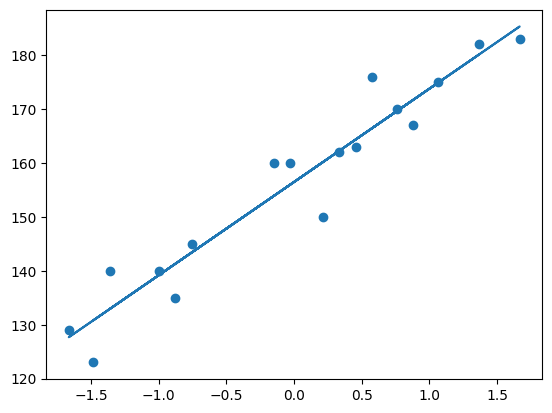

In [45]:
## wrt training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

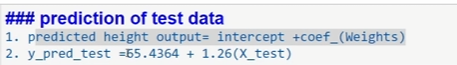

In [47]:
## prediction for the test data

y_pred = regression.predict(X_test)

In [48]:
## performnace metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [49]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


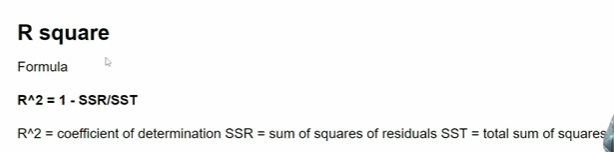

In [50]:
from sklearn.metrics import r2_score

In [51]:
score = r2_score(y_test,y_pred)
print(score)

0.7360826717981276


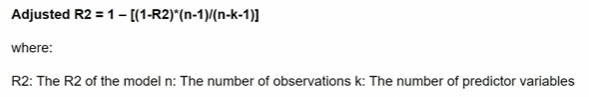

In [53]:
## display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1] - 1)

0.6701033397476595

In [56]:
## OlS linear Regression
!pip install statsmodels
import statsmodels.api as sm


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for statsmodels from https://files.pythonhosted.org/packages/60/15/3daba2df40be8b8a9a027d7f54c8dedf24f0d81b96e54b52293f5f7e3418/statsmodels-0.14.6-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for patsy>=0.5.6 from https://files.pythonhosted.org/packages/f1/70/ba4b949bdc0490ab78d545459acd7702b211dfccf7eb89bbc1060f52818d/patsy-1.0.2-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB 653.6 kB/s eta 0:00:15
    --------------------------------------- 0.1/9.5 MB 1.2 MB/s eta 0:00:08
   - -------------------------------------- 0.3/9.5 MB 1.8 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/9.5 MB 2.3 MB/s eta 0:00:04
   --- ------------------------------------ 0.7/9.5 MB 2.8 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.5 MB 3.

In [58]:
model = sm.OLS(y_train,X_train).fit()

In [59]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [60]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 04 Jul 2026   Prob (F-statistic):                       0.664
Time:                        19:05:24   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [62]:
## prediction for new data
regression.predict(scaler.transform([[72]]))

c:\Users\mayan\OneDrive\Documents\GitHub\udemy_ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])